# Projeto feito por Luiz Trajano:

# Etapa 1: Abrindo o arquivo e analisando conteúdo

In [62]:
import pandas as pd
import os

path_local = 'games.csv'
path_tripleten = '/datasets/games.csv'

# Verifica qual caminho existe e carrega o DataFrame
if os.path.exists(path_tripleten):
    df = pd.read_csv(path_tripleten)
    print("Arquivo carregado da plataforma TripleTen")
elif os.path.exists(path_local):
    df = pd.read_csv(path_local)
    print("Arquivo carregado localmente (VS Code)")
else:
    print("Erro: Arquivo games.csv não encontrado!")

# Prefiro o sample para uma análise rápida variada
df.sample(5)

Arquivo carregado localmente (VS Code)


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
8219,Petz: Horseshoe Ranch,DS,2009.0,Adventure,0.16,0.00,0.00,0.01,NaN,tbd,NaN
8446,One Piece: Pirate Warriors 3,PSV,2015.0,Action,0.00,0.03,0.13,0.01,76.0,6.3,T
14297,Championship Manager Season 01/02,PC,2001.0,Sports,0.00,0.03,0.00,0.00,NaN,NaN,NaN
3697,Ninokuni: Shikkoku no Madoushi,DS,2010.0,Role-Playing,0.00,0.00,0.54,0.00,NaN,NaN,NaN
13171,Dr. Seuss: Green Eggs and Ham,GBA,2003.0,Action,0.04,0.01,0.00,0.00,NaN,9,E


# Etapa 2: preparação dos dados

* Parte 1: passando nomes de colunas para minúsculas:

In [63]:
df.columns = df.columns.str.lower()
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


* Parte 2: conversão dos dados (para caso seja preciso)

In [64]:
print(df.info())
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None



### Observações: 

Acho necessário mudar a coluna do ano, pois está em float, estando seri correto para os dados de ano;

Coluna de user_score mudarei também, pois mudar para float facilita análises numéricas, lembrando que fazendo isso irá alterar os 'tdb' presentes, que seria a falta de avaliações suficientes para cálculos. NaN faria mais sentido pra usar a coluna com sentido numérico;

In [65]:
df['year_of_release'] = df['year_of_release'].astype('Int64')
print(df['year_of_release'].dtype)

Int64


In [66]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
print(df['user_score'].dtype)

float64


### Verificação de dados ausentes relevantes e duplicados:

In [67]:
print(f"Total de duplicados: {df.duplicated().sum()}")

Total de duplicados: 0


In [68]:
print(df.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64


### Observações: 

+ Já tratamos da conversão do year_of_release para int64, portanto só preciso tratar desses NaN se for estritamente preciso, por se tratar de ano de lançamento e ser mais descritivo;

+ Critic_score, user_score, rating: colunas que tem muitos NaN, porém posso tratar deles quando for usar para analisar partes específicas e assim retirá-los. Podem haver muitos valores ausentes por falta de avaliações suficientes para criar o 'score' ou o rating por faltar informação complementar;

+ Corrigir o name e genre, são apenas dois de cada, mas já faço essa correção;

In [69]:
df = df.dropna(subset=['name', 'genre'])
print(df.isna().sum())

name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8576
user_score         9123
rating             6764
dtype: int64


## Criando a soma de vendas em todas as regiões (o 'total_sales')

In [70]:
# preciso usar o axis=1 para garantir que seja por linha a soma
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)

print(df.columns)
print()   
print(df.head())

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'total_sales'],
      dtype='object')

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii             2006        Sports     41.36   
1         Super Mario Bros.      NES             1985      Platform     29.08   
2            Mario Kart Wii      Wii             2008        Racing     15.68   
3         Wii Sports Resort      Wii             2009        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB             1996  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         

# Etapa 3: Análise dos dados

In [71]:
# Os jogos lançados por cada ano, usando o value_counts() para contar a quantidade de jogos por ano
games_per_year = df['year_of_release'].dropna().value_counts().sort_index()
print(games_per_year)

# O ano com mais lançamentos e o ano com menos lançamentos. Usei idxmax() e idxmin() para encontrar os anos correspondentes
# max() e min() para mostrar a quantidade de jogos nesses anos.
print(f"\nAno com mais lançamentos: {games_per_year.idxmax()} ({games_per_year.max()} jogos)")
print(f"Ano com menos lançamentos: {games_per_year.idxmin()} ({games_per_year.min()} jogos)")


year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: Int64

Ano com mais lançamentos: 2008 (1427 jogos)
Ano com menos lançamentos: 1980 (9 jogos)


# Obs: 

Pode-se notar que apartir dos anos 90 em diante houve uma crescente enorme de jogos lançados por ano em diferentes plataformas, mostrando um investimento no mundo da tecnologia e games também ao longo dos anos, ainda assim pode-se ver também que o auge de jogos foi em 2008 e não mais recentemente, podendo ter havido uma vertente de optar por mais qualidade de jogos do que quantidade.

## Analisar a venda por plataforma

In [72]:
# Vendas totais por cada plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(platform_sales.head(10))

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


In [73]:
# Criando o top 5 plataformas
top_platforms = platform_sales.head(5).index
print("\nTop 5 plataformas por vendas totais:")
print(top_platforms)


Top 5 plataformas por vendas totais:
Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')


> Detalhe para o PS2, mostrando o fenômeno no mundo dos games o que esse console foi

In [74]:
# vendas totais por ano para cada plataforma do top 5
# groupby para agrupar por ano e plataforma, sum para somar as vendas, unstack para transformar a plataforma em colunas
sales_by_year = df[df['platform'].isin(top_platforms)].groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack()

# Preencher NaN com 0 para anos sem vendas em alguma plataforma
sales_by_year = sales_by_year.fillna(0)
print("\nVendas totais por ano para as top 5 plataformas:")
print(sales_by_year)


Vendas totais por ano para as top 5 plataformas:
platform             DS     PS2     PS3     Wii    X360
year_of_release                                        
1985               0.02    0.00    0.00    0.00    0.00
2000               0.00   39.17    0.00    0.00    0.00
2001               0.00  166.43    0.00    0.00    0.00
2002               0.00  205.38    0.00    0.00    0.00
2003               0.00  184.31    0.00    0.00    0.00
2004              17.27  211.81    0.00    0.00    0.00
2005             130.14  160.66    0.00    0.00    8.25
2006             119.81  103.42   20.96  137.15   51.62
2007             146.94   75.99   73.19  152.77   95.41
2008             145.31   53.90  118.52  171.32  135.26
2009             119.54   26.40  130.93  206.97  120.29
2010              85.02    5.64  142.17  127.95  170.03
2011              26.18    0.45  156.78   59.65  143.84
2012              11.01    0.00  107.36   21.71   99.74
2013               1.54    0.00  113.25    8.59   88.5

In [75]:
# Ano mais recente com vendas por plataforma
# Assim temos uma visão clara de quais plataformas ainda estão ativas e quais foram descontinuadas,
# além de entender a duração de cada plataforma no mercado.

ano_atual = df['year_of_release'].dropna().max()

platform_data = df.dropna(subset=['year_of_release']).groupby('platform')['year_of_release'].agg(['min', 'max'])
platform_data['lifespan'] = platform_data['max'] - platform_data['min']
platform_data['ainda_ativa'] = platform_data['max'] == ano_atual

# plataformas ainda ativas com boa longevidade
print("=== AINDA ATIVAS (potencial de investimento) ===")
print(platform_data[platform_data['ainda_ativa']].sort_values('lifespan', ascending=False))

# plataformas que morreram cedo (menos de 5 anos)
print("\n=== MORRERAM CEDO (menos de 5 anos) ===")
print(platform_data[(~platform_data['ainda_ativa']) & (platform_data['lifespan'] < 5)].sort_values('lifespan'))

=== AINDA ATIVAS (potencial de investimento) ===
           min   max  lifespan  ainda_ativa
platform                                   
PC        1985  2016        31         True
X360      2005  2016        11         True
Wii       2006  2016        10         True
PS3       2006  2016        10         True
3DS       2011  2016         5         True
PSV       2011  2016         5         True
WiiU      2012  2016         4         True
PS4       2013  2016         3         True
XOne      2013  2016         3         True

=== MORRERAM CEDO (menos de 5 anos) ===
           min   max  lifespan  ainda_ativa
platform                                   
GG        1992  1992         0        False
PCFX      1996  1996         0        False
TG16      1995  1995         0        False
3DO       1994  1995         1        False
SCD       1993  1994         1        False
WS        1999  2001         2        False
NG        1993  1996         3        False
GEN       1990  1994         4

> Vendo os dados, podemos ver que apostando no futuro e modernidade é uma boa saída, sabendo que plataformas como PS4 e XboxOne tendo um futuro ainda pela frente, para saber se terão lucratividade interessantes. Entretanto, investir no 'seguro' em jogos para PC, XBOX e Wii, antes de entrar de vez na modernidade, tem seu valor, gerando receita segura até a modernidade assumir o lugar e as grandes empresas migrarem para seus consoles mais novos.

## Diagrama de caixa para vendas globais

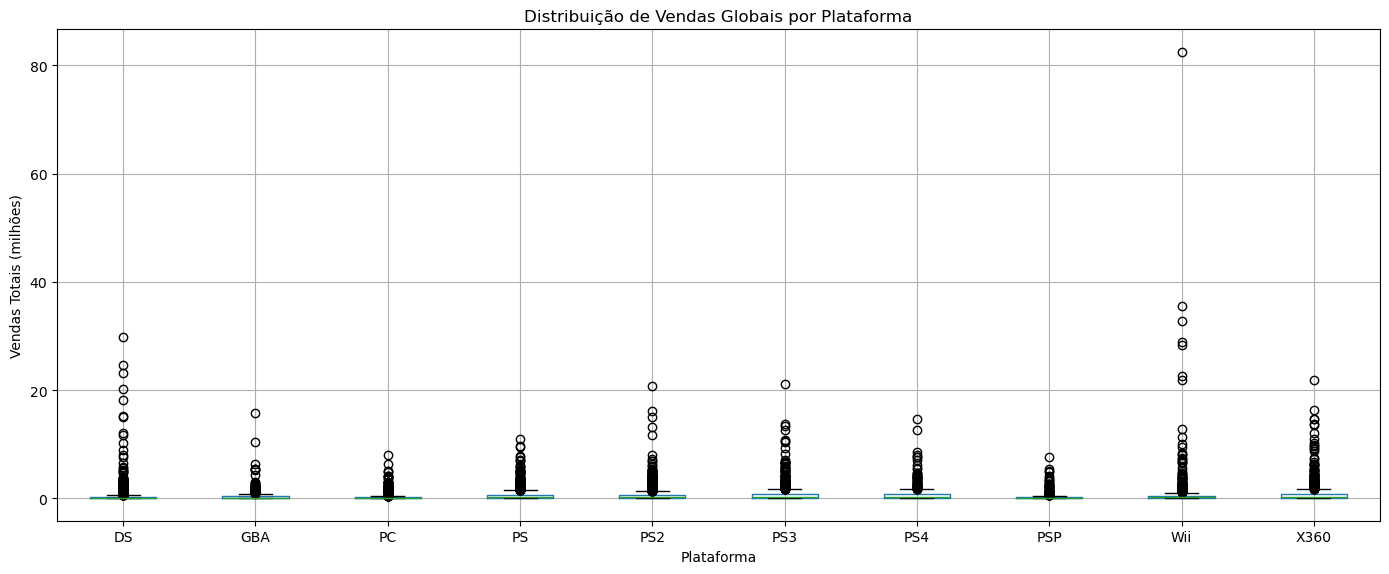

=== VENDAS MÉDIAS POR PLATAFORMA ===
platform
PS4     0.80
X360    0.77
PS3     0.71
Wii     0.69
PS      0.61
PS2     0.58
GBA     0.39
DS      0.37
PC      0.27
PSP     0.24
Name: total_sales, dtype: float64


In [76]:
import matplotlib.pyplot as plt

# filtrar top plataformas para o gráfico não ficar poluído
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(10).index
df_top = df[df['platform'].isin(top_platforms)]

# boxplot
fig, ax = plt.subplots(figsize=(14, 6))
df_top.boxplot(column='total_sales', by='platform', ax=ax)

ax.set_title('Distribuição de Vendas Globais por Plataforma')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Vendas Totais (milhões)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('boxplot_sales.png')
plt.show()

# vendas médias por plataforma
print("=== VENDAS MÉDIAS POR PLATAFORMA ===")
print(df_top.groupby('platform')['total_sales'].mean().sort_values(ascending=False).round(2))

> Como analisado anteriormente as médias provam, que a modernidade vem com tudo para 2017, consoles modernos devem ser a pedida e escolha para novos jogos, tendo em mente que não deixando de lado plataformas ainda rentavéis, até o moderno assumir totalmente o posto de top lucratividade e as antigas irem deixando seu lugar. Detalhe para o outlier lá no topo do wii, mostrando o quanto se venderam jogos pra essa plataforma.

## Plotagem de gráficos

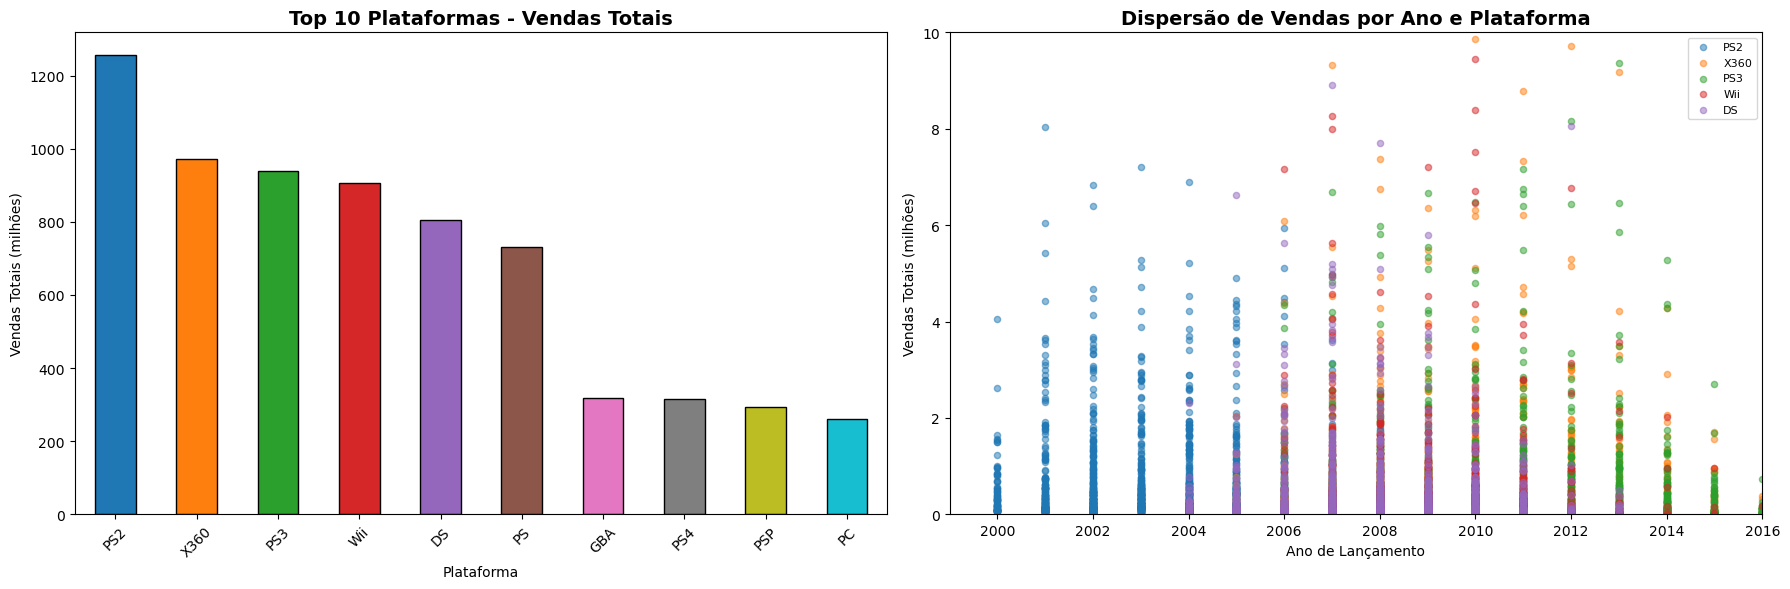

=== PLATAFORMAS POTENCIALMENTE LUCRATIVAS ===
platform
X360    971.42
PS3     939.65
Wii     907.51
PS4     314.14
PC      259.52
3DS     259.00
XOne    159.32
WiiU     82.19
PSV      54.07
Name: total_sales, dtype: float64


In [86]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# vendas totais por plataforma (barras)
colors = plt.cm.tab10.colors
platform_sales.head(10).plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Top 10 Plataformas - Vendas Totais', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Vendas Totais (milhões)')
axes[0].tick_params(axis='x', rotation=45)

# dispersão top 5 plataformas
top_platforms = platform_sales.head(5).index
df_top = df[df['platform'].isin(top_platforms)].dropna(subset=['year_of_release'])

for platform in top_platforms:
    dados = df_top[df_top['platform'] == platform]
    axes[1].scatter(dados['year_of_release'], dados['total_sales'],
                    label=platform, alpha=0.5, s=20)

axes[1].set_title('Dispersão de Vendas por Ano e Plataforma', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano de Lançamento')
axes[1].set_ylabel('Vendas Totais (milhões)')
axes[1].set_ylim(0, 10)
axes[1].set_xlim(1999, df_top['year_of_release'].max())
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('platform_sales.png', dpi=150)
plt.show()

# plataformas potencialmente lucrativas
ano_atual = df['year_of_release'].dropna().max()
platform_data = df.dropna(subset=['year_of_release']).groupby('platform')['year_of_release'].agg(['min', 'max'])
ativas = platform_data[platform_data['max'] == ano_atual].index

print("=== PLATAFORMAS POTENCIALMENTE LUCRATIVAS ===")
print(platform_sales[platform_sales.index.isin(ativas)].head(10))

## Como as avaliações de usuários e profissionais afetam as vendas

Usarei o 'XBOX360' por ser uma plataforma com potencial lucrativo

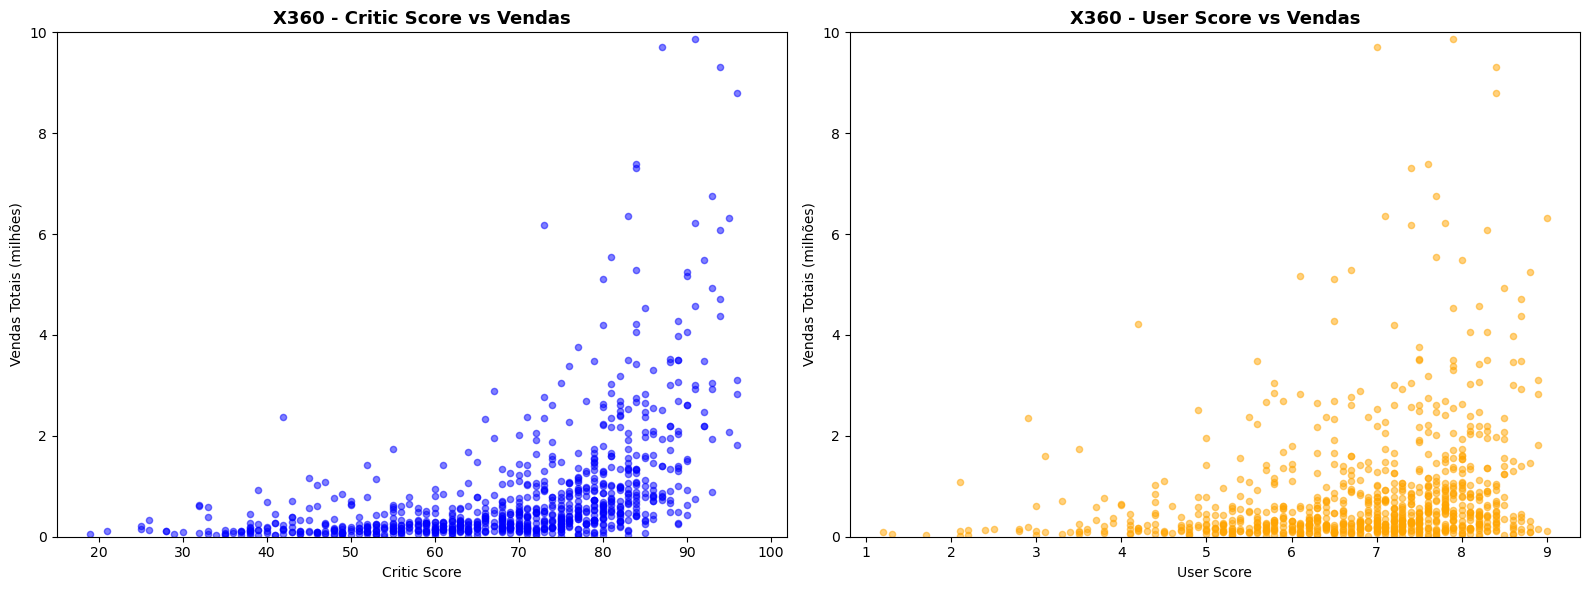

=== CORRELAÇÃO — X360 ===
Critic Score x Vendas: 0.39
User Score x Vendas:   0.11

Avaliação de críticos tem MAIS influência nas vendas


In [97]:
plataforma = 'X360'

df_x360 = df[df['platform'] == plataforma].dropna(subset=['critic_score', 'user_score', 'total_sales'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# critic score x vendas
axes[0].scatter(df_x360['critic_score'], df_x360['total_sales'], alpha=0.5, s=20, color='blue')
axes[0].set_title(f'{plataforma} - Critic Score vs Vendas', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Critic Score')
axes[0].set_ylabel('Vendas Totais (milhões)')
axes[0].set_ylim(0, 10)

# user score x vendas
axes[1].scatter(df_x360['user_score'], df_x360['total_sales'], alpha=0.5, s=20, color='orange')
axes[1].set_title(f'{plataforma} - User Score vs Vendas', fontsize=13, fontweight='bold')
axes[1].set_xlabel('User Score')
axes[1].set_ylabel('Vendas Totais (milhões)')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig('score_vs_sales.png', dpi=150)
plt.show()

# correlação, criando o criterio de comparação entre critic e user score para vendas
corr_critic = df_x360['critic_score'].corr(df_x360['total_sales'])
corr_user = df_x360['user_score'].corr(df_x360['total_sales'])

print(f"=== CORRELAÇÃO — {plataforma} ===")
print(f"Critic Score x Vendas: {corr_critic:.2f}")
print(f"User Score x Vendas:   {corr_user:.2f}")

if corr_critic > corr_user:
    print("\nAvaliação de críticos tem MAIS influência nas vendas")
else:
    print("\nAvaliação de usuários tem MAIS influência nas vendas")

> Como observado nos gráficos e correlações, temos que as avaliações de críticos influenciam mais as vendas do que as dos usuários no X360, mas nenhuma das duas é um fator determinante por termos correlações distantes de 1,0. Isso sugere que outros fatores como marketing, franquia, exclusividade e preço provavelmente têm peso maior nas vendas do que as notas em si.

## 1. Comparando um jogo em diferentes plataformas

## 2. Logo abaixo análise por gêneros dos jogos e lucratividade

In [ ]:
# buscando jogos que foram lançados em 4 ou mais plataformas, para o gráfico de comparação entre plataformas
jogos_multiplataforma = df.groupby('name')['platform'].nunique()
print(jogos_multiplataforma[jogos_multiplataforma >= 4].sort_values(ascending=False).head(5))

name
Need for Speed: Most Wanted    10
Ratatouille                     9
Madden NFL 07                   9
LEGO Marvel Super Heroes        9
FIFA 14                         9
Name: platform, dtype: int64


> Escolha: NEED FOR SPEED: MOST WANTED

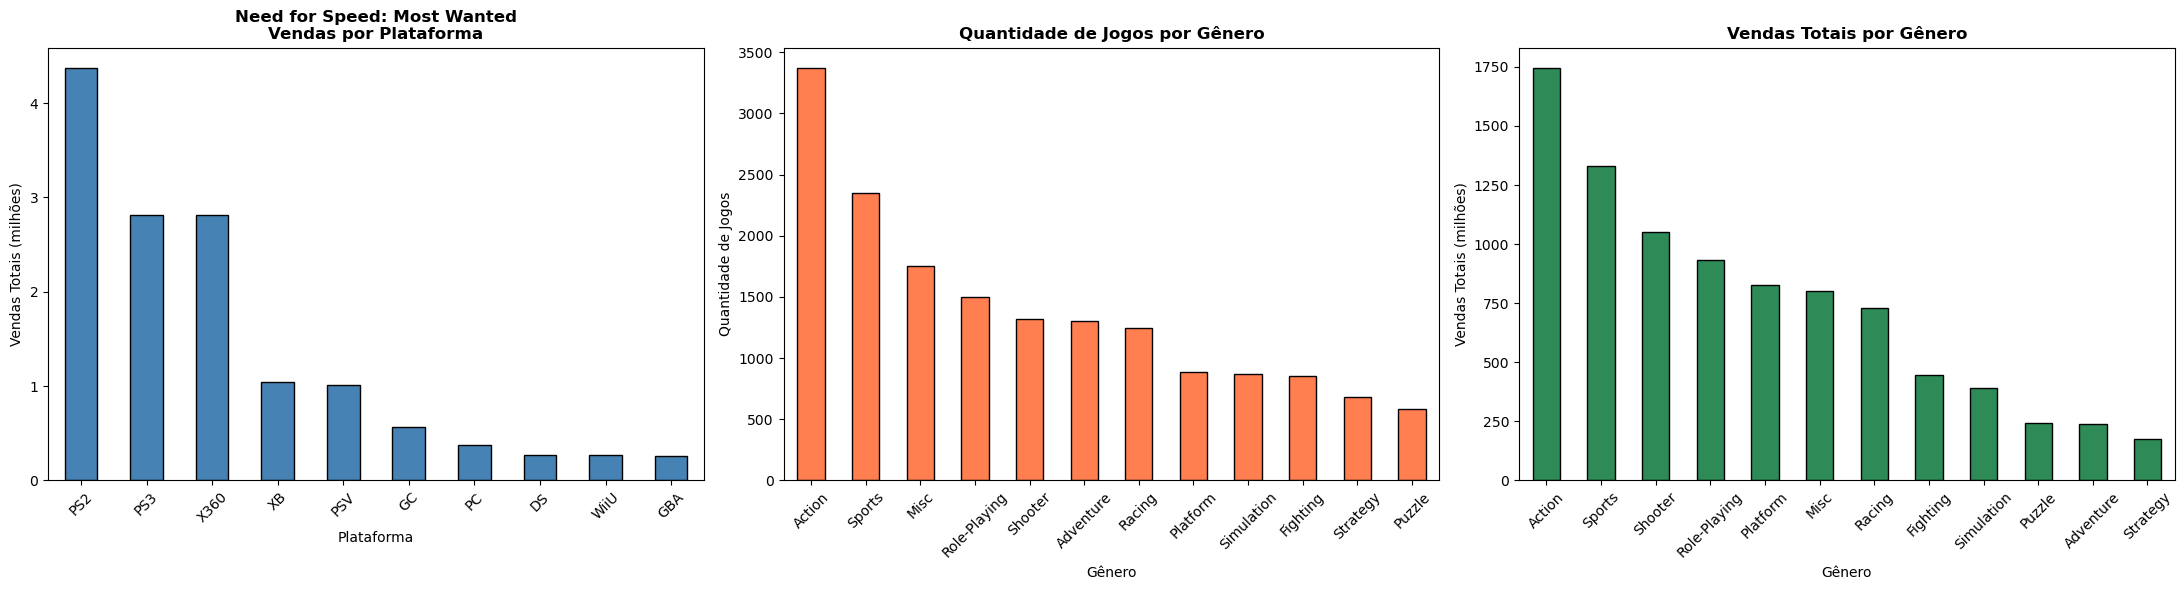

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# mesmo jogo em diferentes plataformas
jogo = 'Need for Speed: Most Wanted'
df_jogo = df[df['name'] == jogo].groupby('platform')['total_sales'].sum().sort_values(ascending=False)

df_jogo.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title(f'{jogo}\nVendas por Plataforma', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Plataforma')
axes[0].set_ylabel('Vendas Totais (milhões)')
axes[0].tick_params(axis='x', rotation=45)

# quantidade de jogos por gênero
genre_count = df['genre'].value_counts()
genre_count.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Quantidade de Jogos por Gênero', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gênero')
axes[1].set_ylabel('Quantidade de Jogos')
axes[1].tick_params(axis='x', rotation=45)

# vendas totais por gênero
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales.plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='black')
axes[2].set_title('Vendas Totais por Gênero', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Gênero')
axes[2].set_ylabel('Vendas Totais (milhões)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('genre_analysis.png', dpi=150)
plt.show()

In [109]:
# vendas médias por gênero (lucratividade real)

print("=== VENDAS MEDIAS POR JOGO (lucratividade por genero) ===")
print(df.groupby('genre')['total_sales'].mean().sort_values(ascending=False))

=== VENDAS MEDIAS POR JOGO (lucratividade por genero) ===
genre
Platform        0.932173
Shooter         0.795503
Role-Playing    0.623872
Racing          0.583403
Sports          0.566980
Fighting        0.527126
Action          0.517711
Misc            0.458577
Simulation      0.446701
Puzzle          0.418224
Strategy        0.255095
Adventure       0.182341
Name: total_sales, dtype: float64


> Na análise ficou evidente que 'action' é: lucrativo por volume, muitos jogos vendendo razoavelmente, já ´platform' é: lucrativo por qualidade, poucos jogos mas cada um vende muito.
> Vale resaltar que gêneros com média alta e volume menor (platform, shooter) tendem a ter franquias dominantes, como jogos mundialmente conhecidos como jogos do Super mario e Call of duty, enquanto gêneros com total alto mas média menor (Action, Sports) são mais competitivos e fragmentados, tendo valores mais altos em vendas nas análise total, porém pelos altos volumes de jogos também.

# Etapa 4: Criando um perfil de usuário para cada região

Para cada região (NA, EU, JP), determinaremos:

+ As cinco plataformas principais.
+ Os cinco principais gêneros.
+ As classificações do ESRB afetam as vendas em regiões individuais?

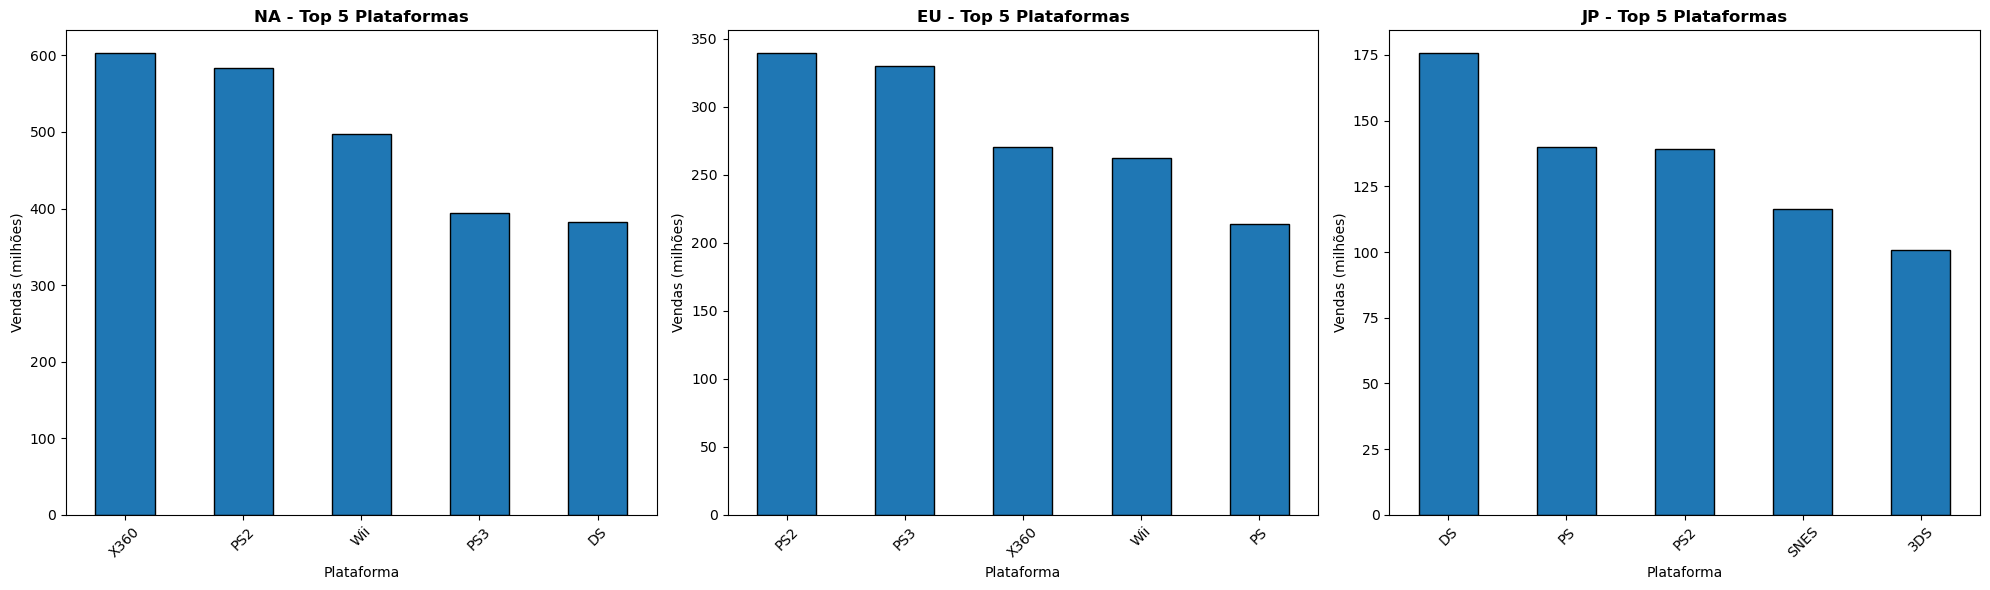

In [124]:
# usando plotagem de gráficos e fazendo divisão por região
# top 5 plataformas por região:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
region = {'NA': 'na_sales', 'EU': 'eu_sales', 'JP': 'jp_sales'}

for col, (region_name, coluna) in enumerate(region.items()):
    top_plat = df.groupby('platform')[coluna].sum().sort_values(ascending=False).head(5)
    top_plat.plot(kind='bar', ax=axes[col], edgecolor='black')
    axes[col].set_title(f'{region_name} - Top 5 Plataformas', fontsize=12, fontweight='bold')
    axes[col].set_xlabel('Plataforma')
    axes[col].set_ylabel('Vendas (milhões)')
    axes[col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('top_plataformas.png', dpi=150)
plt.show()

> Pode-se notar a presença das grandes empresas dos games como nintendo, xbox e playstation apenas em diferentes ordens de mais vendas por região. Entretanto, um detalhe ficou mais claro que em cada região temos um 'campeão' diferente, tendo em NA: X360, EU: PS2 e JP: DS, e no segundo no lugar de cada temos a valiosa empresa da playstation no mundo dos games, mostrando sua força nas variadas regiões do mundo.

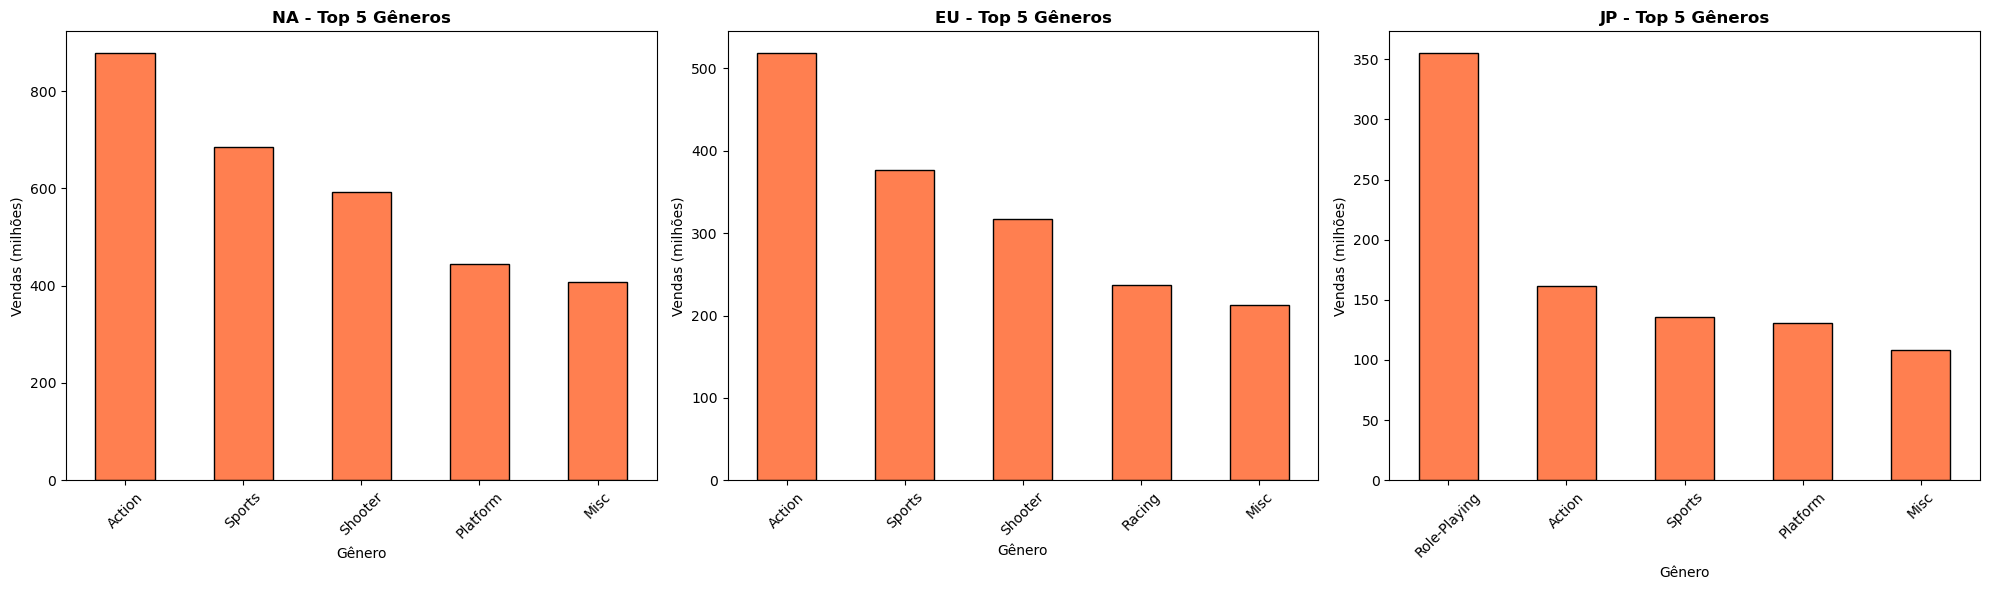

In [126]:
# Top 5 gêneros por região:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, (region_name, coluna) in enumerate(region.items()):
    top_gen = df.groupby('genre')[coluna].sum().sort_values(ascending=False).head(5)
    top_gen.plot(kind='bar', ax=axes[col], color='coral', edgecolor='black')
    axes[col].set_title(f'{region_name} - Top 5 Gêneros', fontsize=12, fontweight='bold')
    axes[col].set_xlabel('Gênero')
    axes[col].set_ylabel('Vendas (milhões)')
    axes[col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('top_generos.png', dpi=150)
plt.show()

> Aqui podemos ver o favoritismo dos gêneros de ação e esportes na América do norte e também Europa, vale citar também os jogos de tiros que em ambos está em terceiro lugar, temos um 'padrão' similar nos mais vendidos. Entretanto, já no Japão, temos os dois gêneros com influência nas preferências dos gamers, porém ainda bem atrás dos jogos role-playing, mostrando que o gosto pode ter padrões diferentes pra os gamers por lá.

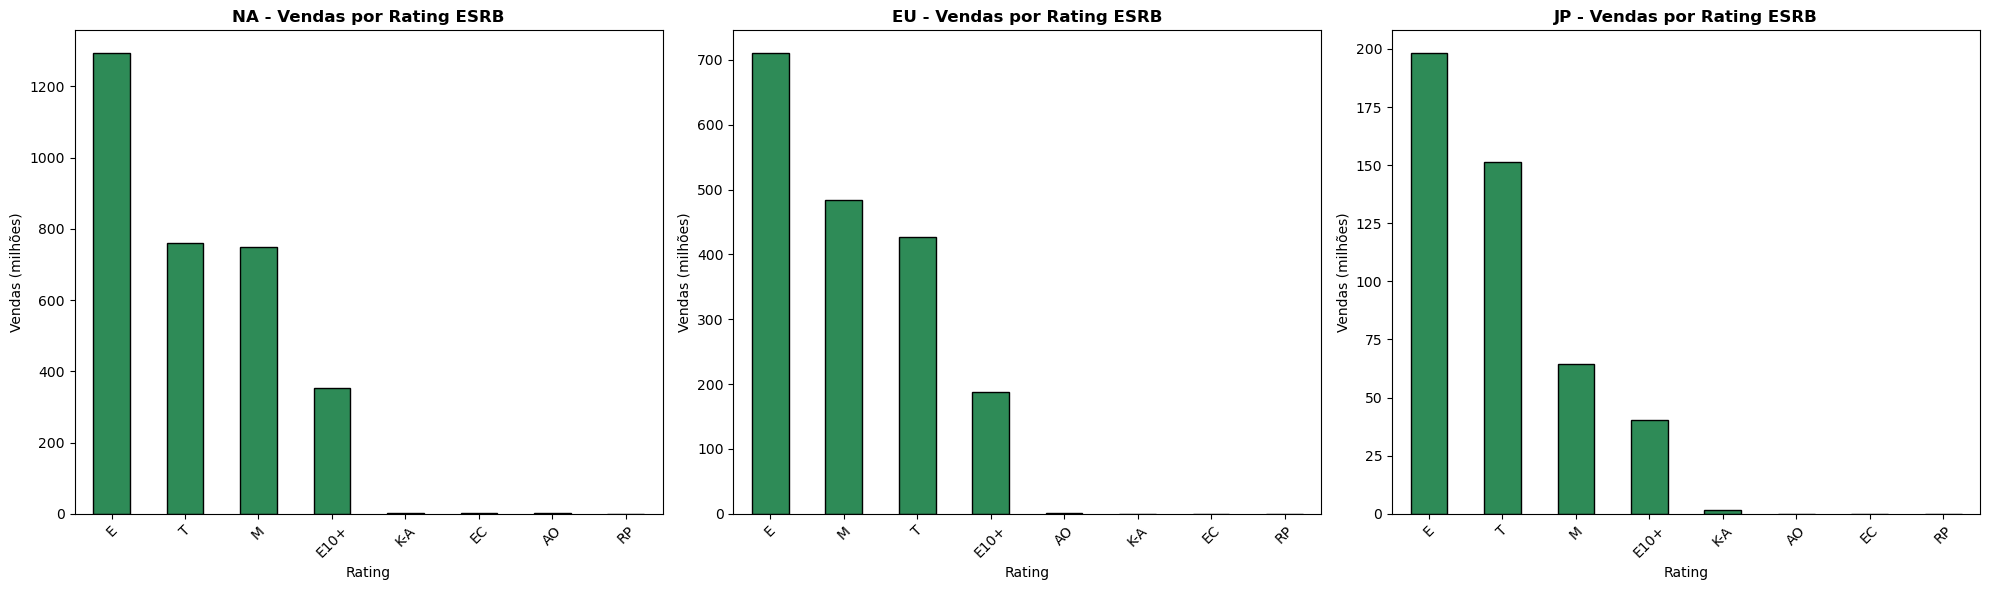

In [127]:
# ESRB Rating por região:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for col, (region_name, coluna) in enumerate(region.items()):
    top_rating = df.dropna(subset=['rating']).groupby('rating')[coluna].sum().sort_values(ascending=False)
    top_rating.plot(kind='bar', ax=axes[col], color='seagreen', edgecolor='black')
    axes[col].set_title(f'{region_name} - Vendas por Rating ESRB', fontsize=12, fontweight='bold')
    axes[col].set_xlabel('Rating')
    axes[col].set_ylabel('Vendas (milhões)')
    axes[col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('esrb_rating.png', dpi=150)
plt.show()

> Em todas as regiões analisadas, pude ver que a classificação livre dos games tem uma diferença bem superior nas vendas que as demais, o que pode estar ligado a grandes títulos que tem esta classifiação e despontam em vendas, a seguir vemos um top 3 similar para todas também apenas alternando na ordem de segundo e terceiro para as classificações pra adolescentes até 13 e depois o M, que é superior a 17, mais ligado a grandes títulos, como GTA que tem essa classficação. Detalhe para o salto realmente grande para o 'E' na região norte americana, mostrando valores bem altos.

# Etapa 5: Testes de hipóteses

— As classificações médias dos usuários das plataformas Xbox One e PC são as mesmas.

— As classificações médias de usuários para os gêneros Action (ação) e Sports (esportes) são diferentes.

Explicar:

— Como formulei as hipóteses alternativas e nulas.

— Qual o nível de significância que escolhi para testar as hipóteses, e por quê.

In [128]:
# nível de significância em 5% para testes estatísticos, por ser o padrão
alpha = 0.05

In [136]:
# teste de hipótese entre xbox e pc

from scipy import stats

xboxone = df[df['platform'] == 'XOne']['user_score'].dropna()
pc = df[df['platform'] == 'PC']['user_score'].dropna()

stat, p_value = stats.ttest_ind(xboxone, pc)

print(f"Teste Xbox One vs PC")
print(f"p-value: {p_value:.4f}")
print(f"Alpha: {alpha}")

if p_value < alpha:
    print("Resultado: REJEITA H0 — as médias são diferentes")
else:
    print("Resultado: NÃO rejeita H0")

Teste Xbox One vs PC
p-value: 0.0000
Alpha: 0.05
Resultado: REJEITA H0 — as médias são diferentes


> Com o p-value = 0 e alpha = 0.05, rejeitamos H0. Há evidências estatísticas suficientes para afirmar que as avaliações médias dos usuários no Xbox One e no PC são diferentes. Isso pode refletir diferenças no perfil dos jogadores de cada plataforma, nos tipos de jogos disponíveis ou nas expectativas de cada comunidade.

In [135]:
# teste de hipótese entre gêneros Action e Sports, para ver se os usuários avaliam de forma diferente esses gêneros
action = df[df['genre'] == 'Action']['user_score'].dropna()
sports = df[df['genre'] == 'Sports']['user_score'].dropna()

stat, p_value = stats.ttest_ind(action, sports)

print(f"Teste Action vs Sports")
print(f"p-value: {p_value:.4f}")
print(f"Alpha: {alpha}")

if p_value < alpha:
    print("Resultado: REJEITA H0 — as médias são diferentes")
else:
    print("Resultado: NÃO rejeita H0")

Teste Action vs Sports
p-value: 0.1041
Alpha: 0.05
Resultado: NÃO rejeita H0


> Com p-value > 0.1 e alpha = 0.05, não rejeitamos H0. Não há evidências estatísticas suficientes para afirmar que as avaliações médias dos usuários nos gêneros Action e Sports são diferentes. Isso sugere que, na percepção dos jogadores, a qualidade percebida entre esses dois gêneros é semelhante, independentemente das diferenças de gameplay. Podemos ver comportamentos um tanto quanto 'parecidos' tendo em vista a popularidade desses games nas vendas, mostrando apreço por quem mais curte esses gêneros.

# **Conclusão**

> **Qualidade dos Dados:**
> O dataset passou por um processo de limpeza essencial: padronização dos nomes das colunas, conversão de tipos (user_score de object para float, year_of_release para Int64), tratamento de valores ausentes e criação da coluna total_sales para facilitar as análises de vendas globais.
>
> **Plataformas:**
> As plataformas com maior volume de vendas são dominadas por consoles da Sony e Microsoft. A análise de ciclo de vida mostrou que a maioria das plataformas tem vida útil entre 5 e 10 anos. As avaliações de críticos têm correlação moderada com as vendas (0.39 no X360), enquanto as avaliações de usuários praticamente não influenciam (0.11) — indicando que marketing e reconhecimento de marca pesam mais que opinião do público.
>
> **Gêneros:**
> Action lidera em volume total de vendas, mas Platform possui a maior média por jogo — sustentada por grandes franquias como Mario e Sonic. Isso revela que mercados de nicho com franquias fortes podem ser tão lucrativos quanto gêneros massivos.
>
> **Análise Regional:**
> Cada região tem preferências distintas: NA e EU são dominadas por consoles ocidentais e gêneros como Action e Shooter, enquanto o JP tem preferência clara por plataformas japonesas e gêneros como Role-Playing — refletindo diferenças culturais significativas no consumo de jogos.
>
> **Testes de Hipótese:**
> Os testes estatísticos confirmaram que Xbox One e PC possuem avaliações médias estatisticamente diferentes (p ≈ 0), enquanto Action e Sports não apresentaram diferença significativa nas avaliações dos usuários (p > 0.1) — sugerindo que o perfil da plataforma influencia mais a percepção do jogador do que o gênero do jogo.
>
> **Observação final:** Na minha opinião, a investida em plataformas da sony e microsoft são de alta valia e principalmente em clássicos dos games, jogos de ação, esportes e role-playing (sendo a pedida maior para o JP). Tendo em mente, que essas vertentes podem vir a trazer ainda mais receita no ano que virá, seria a minha opinião para boas investidas.